# Evaluation Metrics: Keeping Score Honestly

**DCS 404 · Data Science and Machine Learning**

---

Every model we've built ended the same way: a number claiming to say how good it was. An RMSE here, an
accuracy there, an AUC last module. We used those numbers on the way past, but we never stopped to
interrogate them — and metrics *deserve* interrogation, because in machine learning **the metric is the
finish line**. Whatever number you optimize and report, that is what your model becomes good at; if the
number can be gamed, your model will learn to game it, and a model that games its metric is worse than
useless — it's convincingly wrong.

We've already caught metrics misbehaving twice: accuracy flattering a do-nothing classifier on imbalanced
data (the accuracy paradox), and training error applauding a degree-14 polynomial that had memorized noise.
This module makes the interrogation systematic. It is a *toolbox module*: one place that collects, derives,
and stress-tests every score we use — so that when a metric moves, you know exactly what moved and whether
to care.

We take **regression first** — errors you can measure with a ruler — then **classification**, where every
"score" is secretly a table of four numbers and the interesting choices begin.

## How to work through this

The usual rhythm: run every code cell (`Shift + Enter`), study the output, *then* read the commentary.
Cells build on each other, so if something errors, run from the top.

The module is in two halves, plus verdicts:

1. **Sections 1–7 (Regression):** residuals as raw material, then the metric family tree — MAE, MSE, RMSE,
   R², adjusted R², MAPE — each one derived, computed from scratch, checked against scikit-learn, and then
   *stress-tested* until it shows its weakness.
2. **Sections 8–11 (Classification):** the confusion-matrix family consolidated from the last two modules,
   then two genuinely new tools — threshold sweeps done live, and **log loss**, the metric that judges a
   classifier's *probabilities* instead of its labels.
3. **Section 12:** two decision tables — given a problem, which metric do you reach for?

Old friends return so the metrics land on familiar ground: the **Advertising** data from the Regression
module and the **diabetes** data from the Logistic Regression module.

## Learning objectives

After completing this module you will be able to:

- Define, compute (from scratch and with scikit-learn), and interpret **MAE**, **MSE**, **RMSE**, **R²**,
  **adjusted R²**, and **MAPE** for regression models.
- Explain why squaring errors makes RMSE **outlier-sensitive**, and choose between MAE and RMSE based on
  what large errors cost in the domain.
- Interpret R² as *skill relative to a mean-predicting baseline*, explain when it is **negative**, and use
  **adjusted R²** to expose the free lunch of adding junk features.
- Reconstruct the confusion-matrix metrics — **accuracy, precision, recall, F1** — and re-state the
  accuracy paradox from first principles.
- Sweep a classification **threshold** and read precision/recall trade-off curves, PR curves, and
  **ROC/AUC**.
- Evaluate *probability quality* with **log loss** and explain why an overconfident classifier can have
  good accuracy and terrible log loss.
- Select an appropriate metric for a given regression or classification problem — and justify the choice
  in terms of what errors cost.

## Setup

Run this once. Libraries, plotting style, and both datasets: Advertising (regression half) and diabetes
(classification half).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             mean_absolute_percentage_error,
                             accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score, classification_report,
                             log_loss, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay)

# A consistent look for every plot in this notebook
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_palette("deep")
RANDOM_STATE = 42

def load_csv(name, **kwargs):
    for candidate in [Path(f"data/{name}"), Path(f"notebooks/data/{name}")]:
        if candidate.exists():
            print(f"Loaded {name} from: {candidate}")
            return pd.read_csv(candidate, **kwargs)
    raise FileNotFoundError(f"Could not find {name}. Expected it in a data/ folder next to the notebook.")

ads = load_csv("Advertising.csv", index_col=0)        # regression half
diabetes = load_csv("diabetes.csv")                    # classification half
print(f"Advertising: {ads.shape[0]} markets   |   Diabetes: {diabetes.shape[0]} patients")

Loaded Advertising.csv from: data/Advertising.csv
Loaded diabetes.csv from: data/diabetes.csv
Advertising: 200 markets   |   Diabetes: 768 patients


---
## Part A — Regression metrics

### 1. The raw material: residuals

A regression metric is always some way of *summarizing the residuals* — the per-sample errors
$e_i = y_i - \hat{y}_i$ — into a single number. Different summaries emphasize different things; that's the
whole story of this half of the module.

Our workhorse: the Advertising data (200 markets; TV, radio, newspaper budgets → sales), with the multiple
regression from the Regression module refitted on a proper train/test split. All metrics will be computed
on the **test set** — held-out data is the only place a metric means anything, as the overfit polynomial
taught us.

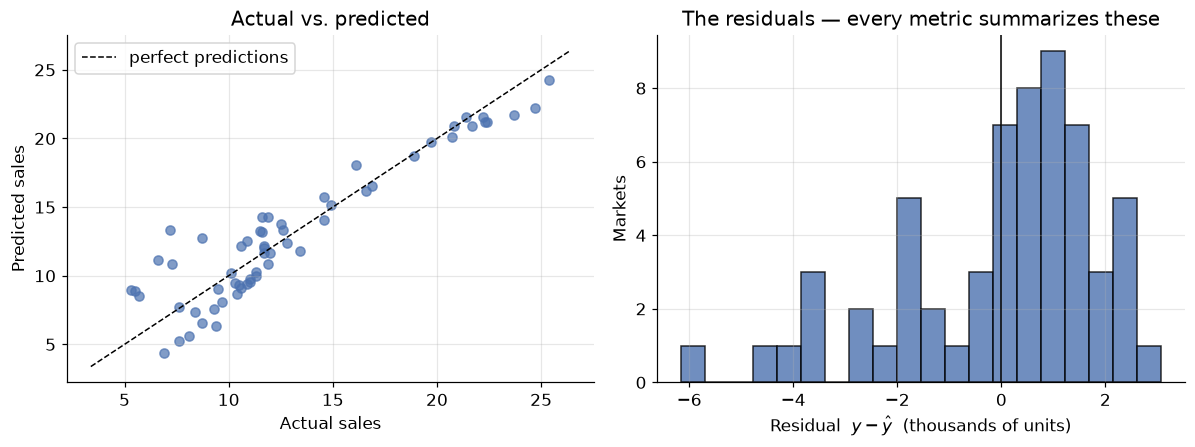

60 test residuals, e.g.: [ 0.33  1.21 -0.15 -3.59  2.5 ]


In [2]:
X_ads = ads[["TV", "radio", "newspaper"]]
y_ads = ads["sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X_ads, y_ads, test_size=0.3, random_state=RANDOM_STATE)

reg = LinearRegression().fit(X_train, y_train)
y_pred = reg.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].scatter(y_test, y_pred, alpha=0.7)
lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
axes[0].plot(lims, lims, "k--", linewidth=1, label="perfect predictions")
axes[0].set_xlabel("Actual sales")
axes[0].set_ylabel("Predicted sales")
axes[0].set_title("Actual vs. predicted")
axes[0].legend()

axes[1].hist(residuals, bins=20, edgecolor="black", alpha=0.8)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("Residual  $y - \\hat{y}$  (thousands of units)")
axes[1].set_ylabel("Markets")
axes[1].set_title("The residuals — every metric summarizes these")

plt.tight_layout()
plt.show()

print(f"{len(residuals)} test residuals, e.g.: {np.round(residuals.values[:5], 2)}")

Sixty test residuals: mostly small, a few sizeable, signs in both directions. Now — how do we compress
sixty numbers into one *fair* number? Not by simply averaging them: positive and negative errors would
cancel, and a model that overshoots half the time and undershoots the other half by the same amount would
score a perfect 0. Every metric below is a different answer to the cancellation problem — and each answer
smuggles in an opinion about *which errors matter most*.

---
### 2. MAE — Mean Absolute Error

The most direct fix: kill the signs with an absolute value, then average.

$$\text{MAE} = \frac{1}{m} \sum_{i=1}^{m} \left| y_i - \hat{y}_i \right|$$

In [3]:
mae_scratch = np.mean(np.abs(y_test - y_pred))
mae_sklearn = mean_absolute_error(y_test, y_pred)

print(f"MAE (from scratch):   {mae_scratch:.4f}")
print(f"MAE (scikit-learn):   {mae_sklearn:.4f}")

MAE (from scratch):   1.5117
MAE (scikit-learn):   1.5117


MAE's superpower is that it *speaks the target's language*: sales are in thousands of units, so our
predictions are off by about 1,500 units on a typical market — a sentence you can say to a stakeholder with
no further translation. Every error counts **in proportion to its size**: a miss of 8 costs exactly twice
a miss of 4. Robust, honest, interpretable.

So why isn't MAE the end of the module? Two reasons. First, a modelling reason: the absolute value has a
kink at zero — no smooth derivative — which is awkward for the calculus-driven optimization we've used all
course. Second, an opinion you may not share: *is* a miss of 8 only twice as bad as a miss of 4? If your
model steers deliveries, one market missed by 8,000 units might be a genuine crisis while two markets
missed by 4,000 are shrugs. Sometimes big errors should count *more than proportionally* — which is
exactly what squaring does.

---
### 3. MSE — Mean Squared Error

Kill the signs by squaring instead:

$$\text{MSE} = \frac{1}{m} \sum_{i=1}^{m} \left( y_i - \hat{y}_i \right)^2$$

This is an old friend wearing a metric's hat — it is (up to a constant) the **cost function that least
squares and gradient descent have been minimizing since the Regression module**. Linear regression is
literally the model that optimizes MSE on the training data; here we're using the same quantity as a
*report card* on the test data.

In [4]:
mse_scratch = np.mean((y_test - y_pred) ** 2)
mse_sklearn = mean_squared_error(y_test, y_pred)

print(f"MSE (from scratch):   {mse_scratch:.4f}")
print(f"MSE (scikit-learn):   {mse_sklearn:.4f}")

MSE (from scratch):   3.7968
MSE (scikit-learn):   3.7968


Squaring does two things at once:

1. **It punishes big errors disproportionately.** A miss of 8 contributes 64; two misses of 4 contribute
   only 32. The metric now *cares* about the worst cases — sometimes exactly what you want.
2. **It wrecks the units.** Our MSE is ≈ 3.8 *squared* thousands-of-units. Nobody thinks in squared
   sales; you cannot put MSE in a sentence for a stakeholder.

Point 1 is a feature or a bug depending on the domain. Point 2 is just a bug — and it has a one-character
fix.

---
### 4. RMSE — Root Mean Squared Error

Take the square root and the units come back:

$$\text{RMSE} = \sqrt{\frac{1}{m} \sum_{i=1}^{m} \left( y_i - \hat{y}_i \right)^2}$$

In [5]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"RMSE: {rmse:.4f}   (same units as sales again)")
print(f"MAE:  {mae_sklearn:.4f}")
print(f"RMSE / MAE ratio: {rmse / mae_sklearn:.2f}")

RMSE: 1.9485   (same units as sales again)
MAE:  1.5117
RMSE / MAE ratio: 1.29


RMSE is the industry's default regression metric: original units like MAE, big-error emphasis like MSE.
Two reading rules:

- **RMSE ≥ MAE, always.** They're equal only if every error has the same size.
- **The gap is a diagnostic.** A ratio near 1 means errors are uniform; a large ratio means a few large
  errors dominate the square. Ours (~1.3) says the errors are moderately spread — consistent with the
  residual histogram in Section 1.

But "big-error emphasis" has a dark side, and it deserves a live demonstration.

#### Stress test: one bad data point

Real datasets contain flukes — a data-entry typo, a market disrupted by a one-off event. Let's corrupt
exactly **one** of our 60 test labels (add 40 to it, as if someone fat-fingered an extra digit) and watch
what each metric does:

In [6]:
y_corrupted = y_test.copy()
y_corrupted.iloc[0] += 40          # one fat-fingered label out of 60

comparison = pd.DataFrame({
    "clean data": [mean_absolute_error(y_test, y_pred),
                   np.sqrt(mean_squared_error(y_test, y_pred))],
    "1 outlier in 60": [mean_absolute_error(y_corrupted, y_pred),
                        np.sqrt(mean_squared_error(y_corrupted, y_pred))],
}, index=["MAE", "RMSE"])
comparison["increase"] = (comparison["1 outlier in 60"] / comparison["clean data"] - 1
                          ).map("{:+.0%}".format)
comparison.round(3)

,clean data,1 outlier in 60,increase
MAE,1.512,2.178,+44%
RMSE,1.949,5.560,+185%


One corrupted label out of sixty and RMSE nearly **triples**, while MAE rises by well under half. Neither
metric is "wrong" — they answer different questions:

- **MAE** answers: *how large is the typical error?* Use it when large errors are no worse than their size
  suggests — or when your data has outliers you don't want dictating the verdict.
- **RMSE** answers: *how large are the errors, with the worst ones counted extra?* Use it when large
  errors are disproportionately costly (energy load forecasting, inventory) — and your labels are clean.

The general principle, worth engraving: **an outlier-sensitive metric can't tell you whether the model is
bad or one label is bad.** If RMSE looks alarming, check the residuals before blaming the model.

---
### 5. R² — skill, relative to a baseline

MAE and RMSE share a blind spot: they're **scale-bound**. Is RMSE = 1.9 good? For sales in the 1–27 range,
probably; for temperatures in the 20–22 range, catastrophic. Without knowing the target's spread, the
number floats free.

R² fixes this by asking a sharper question: **how much better is the model than the laziest possible
competitor** — a "model" that ignores the features and predicts the mean $\bar{y}$ for everyone?

$$R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}
      = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

The denominator is the squared error *of the mean-predictor*; the numerator is the squared error *of our
model*. Their ratio is "what fraction of the baseline's error we still make", and one-minus-that is the
fraction we've eliminated — commonly read as **the fraction of the target's variance the model explains**.

In [7]:
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - y_test.mean()) ** 2)
r2_scratch = 1 - ss_res / ss_tot

print(f"R² (from scratch):   {r2_scratch:.4f}")
print(f"R² (scikit-learn):   {r2_score(y_test, y_pred):.4f}")
print(f"→ The model explains about {r2_scratch:.0%} of the variance in sales.")

R² (from scratch):   0.8609
R² (scikit-learn):   0.8609
→ The model explains about 86% of the variance in sales.


The reading scale:

- $R^2 = 1$ — perfect predictions ($\text{SS}_{\text{res}} = 0$).
- $R^2 = 0$ — no better than predicting the mean. The features bought you nothing.
- $R^2 < 0$ — **worse than predicting the mean.** Yes, this happens, and no, it's not a bug.

That last line surprises everyone once. On *training* data (with an intercept) least squares can never do
worse than the mean, so classroom R² lives in [0, 1]. But on **test** data there's no such guarantee — a
badly overfit model can be genuinely worse than the laziest baseline. Let's manufacture both edge cases:

In [8]:
# Edge case 1: the lazy baseline itself, evaluated on the test set
baseline_pred = np.full(len(y_test), y_train.mean())
print(f"R² of predict-the-training-mean: {r2_score(y_test, baseline_pred):.4f}   (≈ 0, as designed)")

# Edge case 2: our old enemy — a degree-10 polynomial fitted to just 12 training markets
overfit = make_pipeline(PolynomialFeatures(10), StandardScaler(), LinearRegression())
overfit.fit(X_train[["TV"]].iloc[:12], y_train.iloc[:12])
print(f"R² of an overfit degree-10 polynomial: {r2_score(y_test, overfit.predict(X_test[['TV']])):.2f}")

R² of predict-the-training-mean: -0.0917   (≈ 0, as designed)
R² of an overfit degree-10 polynomial: -27.10


The baseline scores ≈ 0 (slightly off because the *training* mean isn't exactly the test mean), and the
overfit polynomial scores catastrophically negative — its wild swings between training points make it far
worse than just guessing the average. **A negative test R² is one of the loudest overfitting alarms in the
toolbox.**

Two cautions before we move on:

- **R² says nothing about absolute error.** R² = 0.86 with RMSE = 1.9 might be simultaneously "excellent
  variance explained" and "too imprecise for your use case". Report R² *with* MAE or RMSE, not instead.
- **On training data, R² only ever goes up as you add features** — any feature, even garbage. That free
  lunch is the next section's target.

---
### 6. Adjusted R² — charging rent for features

Watch the free lunch happen. We'll append columns of **pure random noise** to the Advertising features and
refit. The noise contains no information about sales whatsoever — yet training R² will rise:

In [9]:
rng = np.random.default_rng(0)

def adjusted_r2(r2, n, p):
    """Adjusted R²: n samples, p features."""
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

rows = []
for n_junk in [0, 5, 20, 60]:
    Xj_train = np.c_[X_train.values, rng.normal(size=(len(X_train), n_junk))]
    Xj_test = np.c_[X_test.values, rng.normal(size=(len(X_test), n_junk))]

    model = LinearRegression().fit(Xj_train, y_train)
    r2_train = model.score(Xj_train, y_train)
    rows.append({
        "junk features added": n_junk,
        "train R²": r2_train,
        "train adjusted R²": adjusted_r2(r2_train, len(y_train), 3 + n_junk),
        "test R²": model.score(Xj_test, y_test),
    })

pd.DataFrame(rows).set_index("junk features added").round(4)

,train R²,train adjusted R²,test R²
junk features added,,,
0,0.9055,0.9034,0.8609
5,0.9116,0.9062,0.8613
20,0.9158,0.8991,0.8412
60,0.9467,0.9025,0.8175


Read the three columns left to right:

- **Train R² rises monotonically** — with 60 noise columns the model finds enough chance correlations to
  "explain" several extra points of variance. Pure illusion.
- **Test R² falls** — the noise-fitting is overfitting, and held-out data says so.
- **Adjusted R² falls too** — and it saw *only training data*. That's its trick:

$$R^2_{\text{adj}} = 1 - \left(1 - R^2\right)\frac{n - 1}{n - p - 1}$$

where $n$ is the number of samples and $p$ the number of features. Each extra feature shrinks the
denominator $n - p - 1$, inflating the penalty factor — so a new feature must improve R² by *more than
chance would* to move adjusted R² upward. It's a leaner cousin of the Regularization module's idea: make
complexity pay rent.

**When to reach for it:** comparing models with *different feature counts* on the same training data —
classic statistics workflow. When you have a proper held-out set (our usual workflow), test-set metrics
remain the gold standard; adjusted R² is the tool for when you can't afford one.

---
### 7. MAPE — Mean Absolute Percentage Error

One question none of the metrics above can answer: *is an error of 1.5 big?* It depends — 1,500 units
missing from a 25,000-unit market is rounding error; from a 3,000-unit market it's half the business.
MAPE rescales each error by the true value, making errors **relative**:

$$\text{MAPE} = \frac{1}{m} \sum_{i=1}^{m} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

In [10]:
mape_scratch = np.mean(np.abs((y_test - y_pred) / y_test))
mape_sklearn = mean_absolute_percentage_error(y_test, y_pred)

print(f"MAPE (from scratch):   {mape_scratch:.4f}")
print(f"MAPE (scikit-learn):   {mape_sklearn:.4f}")
print(f"→ Predictions are off by about {mape_sklearn:.0%} of each market's actual sales, on average.")

MAPE (from scratch):   0.1630
MAPE (scikit-learn):   0.1630
→ Predictions are off by about 16% of each market's actual sales, on average.


Percentages travel well: you can compare a sales model against a temperature model, or this quarter's
model against last year's, without unit gymnastics. That makes MAPE a favourite in forecasting.

Its fine print is sharp, though:

- **Division by $y_i$ explodes near zero.** One test sample with true value 0.01 can dominate the entire
  metric — and a true zero is a division by zero. Never use MAPE for targets that touch zero (demand that
  can be nil, account balances…).
- **It's asymmetric.** Predicting 150 when truth is 100 scores 50%; predicting 100 when truth is 150
  scores 33% — the *same absolute miss*, punished differently. MAPE systematically favours
  *under*-prediction.

#### The regression scoreboard, complete

In [11]:
scoreboard = pd.DataFrame({
    "value": [mean_absolute_error(y_test, y_pred),
              mean_squared_error(y_test, y_pred),
              np.sqrt(mean_squared_error(y_test, y_pred)),
              r2_score(y_test, y_pred),
              adjusted_r2(r2_score(y_test, y_pred), len(y_test), 3),
              mean_absolute_percentage_error(y_test, y_pred)],
}, index=["MAE", "MSE", "RMSE", "R²", "adjusted R²", "MAPE"])
scoreboard.round(4)

,value
MAE,1.5117
MSE,3.7968
RMSE,1.9485
R²,0.8609
adjusted R²,0.8535
MAPE,0.1630


One model, six honest numbers, six different sentences about it. Which sentence you lead with is Section
12's business. First — classification.

---
## Part B — Classification metrics

### 8. Why classification scoring is harder

A regression error has a *size* — summarizing sizes is all Part A did. A classification error has no size;
it has a **type**. Calling a diabetic patient healthy and calling a healthy patient diabetic are both
"one error", but they are different *kinds* of wrong, with different costs. Any single number that forgets
the distinction is hiding something — that was the moral of the last two modules, and now we assemble the
whole toolbox in one place.

Our workhorse: the diabetes data with last module's rematch models — logistic regression and a pruned
decision tree. We'll score them side by side throughout.

In [12]:
X_diab = diabetes.drop("Outcome", axis=1)
y_diab = diabetes["Outcome"]
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_diab, y_diab, test_size=0.3, random_state=RANDOM_STATE)

clf_logreg = make_pipeline(StandardScaler(), LogisticRegression()).fit(Xd_train, yd_train)
clf_tree = DecisionTreeClassifier(random_state=12, ccp_alpha=0.005).fit(Xd_train, yd_train)

yd_pred = clf_logreg.predict(Xd_test)          # logistic regression is our main subject
proba = clf_logreg.predict_proba(Xd_test)[:, 1]

print(f"Logistic regression accuracy: {accuracy_score(yd_test, yd_pred):.3f}")
print(f"Decision tree accuracy:       {clf_tree.score(Xd_test, yd_test):.3f}")
print(f"Always-predict-healthy:       {(yd_test == 0).mean():.3f}   ← the baseline to beat")

Logistic regression accuracy: 0.736
Decision tree accuracy:       0.723
Always-predict-healthy:       0.654   ← the baseline to beat


There is the **accuracy paradox** in one screen: the do-nothing baseline scores 65% because two-thirds of
patients are healthy, so our models' ≈73% is far less impressive than it sounds — and on a rarer disease
the baseline would beat any honest model. Accuracy averages over error *types*; to see the types we open
the confusion matrix.

### 9. The confusion matrix and its children

Everything in binary classification scoring is a ratio of the four cells (positive class = has diabetes):

<div align="center">
<img src="resources/images/confusion_matrix.png" width="380">

*Figure 1 — TN, FP (Type I error), FN (Type II error), TP. Rows: actual; columns: predicted.*
</div>

TN=120  FP=31  FN=30  TP=50


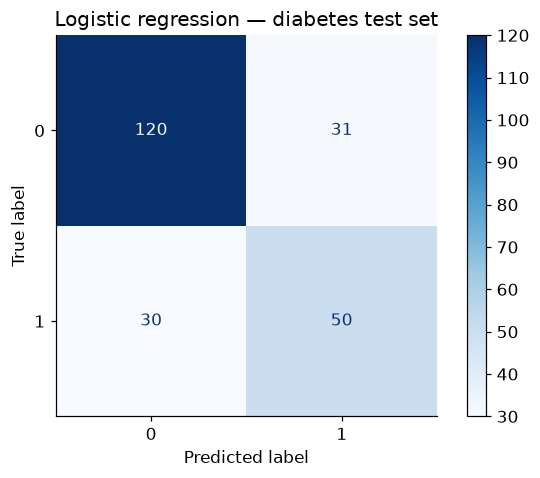

In [13]:
tn, fp, fn, tp = confusion_matrix(yd_test, yd_pred).ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

ConfusionMatrixDisplay.from_estimator(clf_logreg, Xd_test, yd_test, cmap="Blues")
plt.title("Logistic regression — diabetes test set")
plt.grid(False)
plt.show()

The three ratios that matter, in one place (details in the Logistic Regression module, Section 9):

| Metric | Formula | The question it answers | Optimize it when… |
|---|---|---|---|
| **Accuracy** | $\frac{TP+TN}{\text{all}}$ | How often is the model right? | classes balanced, both errors equal cost |
| **Precision** | $\frac{TP}{TP+FP}$ | When it says *positive*, is it right? | false alarms are expensive (spam filter) |
| **Recall** | $\frac{TP}{TP+FN}$ | Of the real positives, how many found? | misses are expensive (disease screening) |
| **F1** | $\frac{2 \cdot P \cdot R}{P + R}$ | Balance of the two (harmonic mean) | you need one number and classes are skewed |

In [14]:
print(f"Precision: {precision_score(yd_test, yd_pred):.3f}")
print(f"Recall:    {recall_score(yd_test, yd_pred):.3f}")
print(f"F1 score:  {f1_score(yd_test, yd_pred):.3f}\n")
print(classification_report(yd_test, yd_pred, target_names=["healthy (0)", "diabetic (1)"]))

Precision: 0.617
Recall:    0.625
F1 score:  0.621

              precision    recall  f1-score   support

 healthy (0)       0.80      0.79      0.80       151
diabetic (1)       0.62      0.62      0.62        80

    accuracy                           0.74       231
   macro avg       0.71      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231



For a screening tool, that recall row is the headline: roughly a third of the true diabetics walk out
undiagnosed. Which raises the question the next section answers live: those metrics were computed at the
default 0.5 threshold — *what if we move it?*

### 10. Metrics are functions of the threshold

`predict` is just `predict_proba` plus a cutoff. The cutoff is **ours to choose**, and every choice buys
recall with precision or vice versa. In the Logistic Regression module this was an exercise; now let's
sweep the whole dial and plot the trade-off:

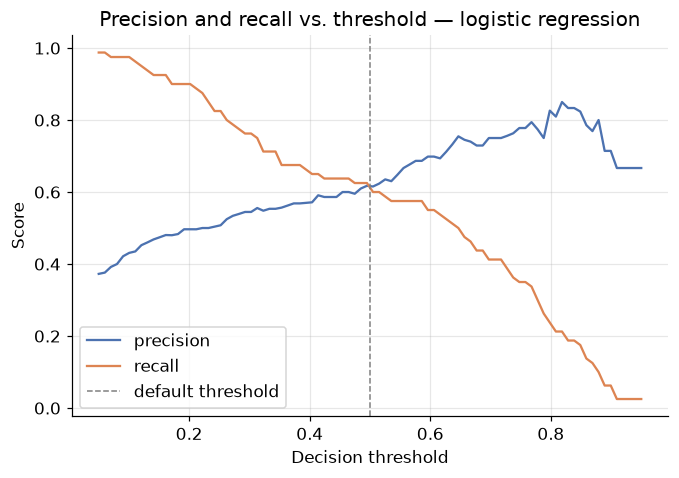

threshold 0.3:  precision=0.54  recall=0.76
threshold 0.5:  precision=0.62  recall=0.62
threshold 0.7:  precision=0.75  recall=0.41


In [15]:
thresholds = np.linspace(0.05, 0.95, 90)
precisions, recalls = [], []
for t in thresholds:
    yt = (proba >= t).astype(int)
    precisions.append(precision_score(yd_test, yt, zero_division=1))
    recalls.append(recall_score(yd_test, yt))

plt.plot(thresholds, precisions, label="precision")
plt.plot(thresholds, recalls, label="recall")
plt.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="default threshold")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Precision and recall vs. threshold — logistic regression")
plt.legend()
plt.show()

for t in [0.3, 0.5, 0.7]:
    yt = (proba >= t).astype(int)
    print(f"threshold {t}:  precision={precision_score(yd_test, yt):.2f}  "
          f"recall={recall_score(yd_test, yt):.2f}")

The scissors pattern: lower the threshold and recall climbs (flag more people → catch more diabetics)
while precision sinks (more false alarms); raise it and they swap. **No threshold is "correct"** — a cheap
follow-up test justifies 0.3; an invasive treatment justifies 0.7. The model supplies the menu; the domain
picks the dish.

Since each threshold yields one (precision, recall) or one (TPR, FPR) pair, sweeping the dial traces the
two curves from the Decision Trees module — **PR curve** and **ROC curve**, with **AUC** condensing the
latter into a single threshold-free number (1.0 perfect, 0.5 random). One cell, both curves, both models:

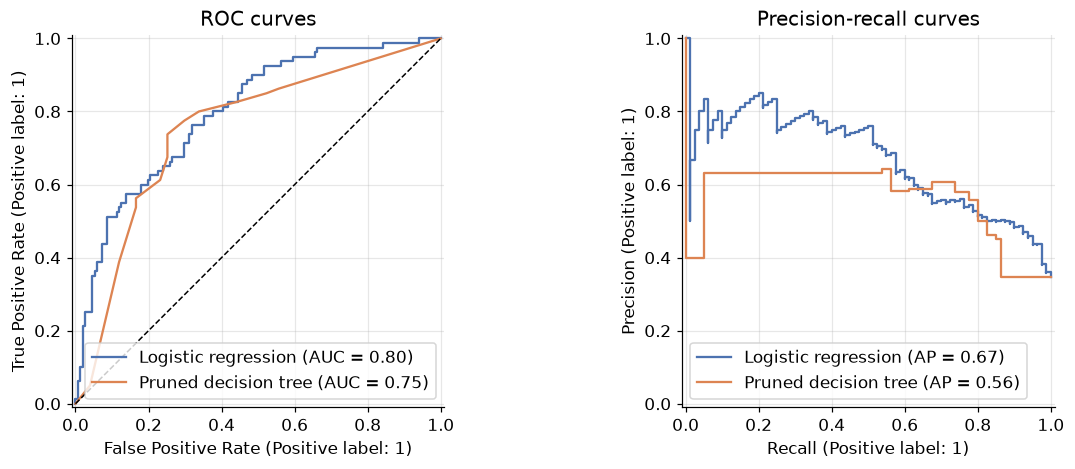

Logistic regression  AUC = 0.798
Pruned tree          AUC = 0.752


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

for model, name in [(clf_logreg, "Logistic regression"), (clf_tree, "Pruned decision tree")]:
    RocCurveDisplay.from_estimator(model, Xd_test, yd_test, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_estimator(model, Xd_test, yd_test, name=name, ax=axes[1])

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_title("ROC curves")
axes[1].set_title("Precision-recall curves")
plt.tight_layout()
plt.show()

for model, name in [(clf_logreg, "Logistic regression"), (clf_tree, "Pruned tree")]:
    print(f"{name:<20} AUC = {roc_auc_score(yd_test, model.predict_proba(Xd_test)[:, 1]):.3f}")

Use AUC to *compare models before committing to a threshold*; use the threshold sweep to *choose the
operating point* once the domain costs are on the table. Two tools, two different moments in the workflow.

### 11. Log loss — grading the probabilities themselves

One dimension remains unexamined. Accuracy & co. judge the *labels*; AUC judges the *ranking*; but many
applications consume the **probability itself** — a 90% diabetes risk and a 51% risk trigger very
different clinical responses, even though both round to "positive". A model whose probabilities are
*trustworthy* deserves credit; one that is confidently wrong deserves punishment.

The metric for this is **log loss** — and you already know it by another name: it is exactly the **binary
cross-entropy** that logistic regression *minimizes during training* (Logistic Regression module, Section 6),
now repurposed as a report card:

$$\text{Log loss} = -\frac{1}{m} \sum_{i=1}^m \Big[ y_i \log \hat{p}_i + (1 - y_i)\log(1 - \hat{p}_i) \Big]$$

Lower is better; 0 is perfection. The log makes confident mistakes catastrophic: predicting $\hat{p} =
0.99$ for a healthy patient costs $-\log(0.01) \approx 4.6$, while a humble 0.6 costs only 0.9. Watch it
separate our two models — *and* a fully grown tree, which classifies decently but speaks only in
certainties:

In [17]:
tree_full = DecisionTreeClassifier(random_state=12).fit(Xd_train, yd_train)   # unpruned

rows = []
for name, model in [("Logistic regression", clf_logreg),
                    ("Pruned tree", clf_tree),
                    ("Fully grown tree", tree_full)]:
    p = model.predict_proba(Xd_test)[:, 1]
    rows.append({"model": name,
                 "accuracy": accuracy_score(yd_test, model.predict(Xd_test)),
                 "AUC": roc_auc_score(yd_test, p),
                 "log loss": log_loss(yd_test, p)})

pd.DataFrame(rows).set_index("model").round(3)

,accuracy,AUC,log loss
model,,,
Logistic regression,0.736,0.798,0.523
Pruned tree,0.723,0.752,1.491
Fully grown tree,0.710,0.708,10.454


The punchline is the last row: the fully grown tree's accuracy is in the same neighbourhood as the
others, but its log loss is **an order of magnitude worse**. Why? Its pure leaves output probabilities of
exactly 0 or 1 — and every time one of those certainties is wrong, the logarithm detonates. The pruned
tree's leaves are mixed, its probabilities humbler, its log loss far saner; logistic regression, which was
*trained* to minimize this very quantity, wins comfortably.

Moral: **accuracy measures how often you're right; log loss measures whether your confidence can be
trusted.** If downstream decisions consume the probability (risk scores, triage, bidding), evaluate with
log loss — it will catch overconfident models that accuracy waves through.

#### Multiclass postscript

Everything here generalizes to $K$ classes exactly as the Decision Trees module showed: the confusion
matrix becomes $K \times K$, per-class precision/recall/F1 get combined by **macro / weighted / micro**
averaging, and log loss becomes cross-entropy. As a reminder of where the levers are:

In [18]:
iris = load_iris()
Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=RANDOM_STATE, stratify=iris.target)

clf_iris = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE).fit(Xi_train, yi_train)
yi_pred = clf_iris.predict(Xi_test)

for avg in ["macro", "weighted", "micro"]:
    print(f"{avg:>9} F1: {f1_score(yi_test, yi_pred, average=avg):.4f}")

    macro F1: 0.9333
 weighted F1: 0.9333
    micro F1: 0.9333


---
## 12. Choosing a metric: the decision tables

The single most important sentence of the module: **choosing the metric is a modelling decision — make it
before you evaluate, based on what errors cost in the domain.** The tables below compress both halves into
that decision.

### Regression

| You want to know… | Reach for | Watch out for |
|---|---|---|
| Typical error, in the target's units | **MAE** | treats a huge miss as merely proportionally bad |
| Error with the worst cases counted extra | **RMSE** | one outlier label can dominate it |
| The quantity your OLS/GD training optimized | **MSE** | squared units — don't quote it to humans |
| Skill relative to predicting the mean | **R²** | says nothing about absolute error; negative = alarm |
| R² when comparing different feature counts (no test set) | **adjusted R²** | still a training-data metric |
| Scale-free % error, comparable across problems | **MAPE** | explodes near zero targets; favours under-prediction |

*Default reporting habit: RMSE (or MAE) together with R² — one absolute, one relative.*

### Classification

| Your situation | Reach for | Watch out for |
|---|---|---|
| Balanced classes, equal error costs | **accuracy** | the paradox: worthless under imbalance |
| False alarms are expensive | **precision** | can be gamed by predicting positive rarely |
| Misses are expensive (screening, fraud) | **recall** | can be gamed by flagging everyone |
| One number, imbalanced classes | **F1** | hides *which* of P/R is weak — read both |
| Comparing models before choosing a threshold | **ROC-AUC** | insensitive to calibration; optimistic under heavy imbalance (prefer PR curve) |
| Downstream code consumes the probabilities | **log loss** | brutal on overconfidence — which is the point |
| Multiclass, rare classes matter | **macro F1** | weighted/micro will mask rare-class failure |

*Default reporting habit: the full `classification_report` plus AUC — then the one metric your domain
actually optimizes, chosen out loud.*

---
## 13. Your turn

Add cells below each exercise. Exercises 2 and 4 consolidate the big ideas.

**Exercise 1 — The scoreboard, by hand.**
Compute MAE, RMSE, and R² for the *TV-only* simple regression (fit `LinearRegression` on just the `TV`
column) on our test split, without using any `sklearn.metrics` functions — numpy only. Check yourself
against scikit-learn. How much does dropping radio and newspaper cost in each metric?

**Exercise 2 — Design the metric for the domain.**
For each scenario, pick the *one* metric you would optimize, and defend it in a sentence: (a) forecasting
electricity demand, where under-supply causes blackouts; (b) predicting house prices for a listings
website across cities with wildly different price levels; (c) a spam filter for a hospital's email;
(d) ranking loan applicants by default risk for a human reviewer who reads the top 100.

**Exercise 3 — MAPE's blind spot, live.**
Create `y_tiny = y_test.copy()` and set its first value to 0.1. Recompute MAPE and MAE against the same
predictions. Which metric just became useless, and why? What does this tell you about *checking the
target's range* before choosing MAPE?

**Exercise 4 — Calibration vs. accuracy.**
Take the fully grown diabetes tree from Section 11. Using `np.clip`, squash its predicted probabilities
into the range [0.05, 0.95] and recompute the log loss. Accuracy hasn't changed (the labels are the same
— why?), but log loss improves dramatically. Explain in two sentences what this "clipping" did and why a
model that hedges its bets scores better here.

**Exercise 5 — The full report.**
Write a function `evaluate_classifier(model, X_test, y_test)` that prints the confusion matrix, the
classification report, ROC-AUC, and log loss, and draws the ROC and PR curves side by side. Run it on both
diabetes models. This function is worth keeping — you'll use it for every classifier you build after this
course.

---
## 14. If you remember nothing else

1. **A metric is a summary of residuals (regression) or of the confusion matrix (classification), and
   every summary has an opinion.** Know the opinion before you trust the number.

2. **MAE = typical error in real units; RMSE = the same but with big errors counted extra.** RMSE ≥ MAE
   always; a wide gap means a few large errors dominate — and one bad label can triple RMSE while barely
   moving MAE.

3. **R² is skill versus the predict-the-mean baseline** — 1 perfect, 0 useless, negative = worse than
   lazy (a loud overfitting alarm on test data). It's relative: always pair it with an absolute metric.
   **Adjusted R²** charges rent per feature and exposes the junk-feature free lunch on training data.

4. **MAPE speaks percentages** and travels across scales — but never point it at targets that touch zero,
   and remember it forgives under-prediction more than over-prediction.

5. **Accuracy averages over error types; the confusion matrix separates them.** Precision guards against
   false alarms, recall against misses, F1 balances — and all of them are functions of a *threshold you
   chose*. Sweep it: ROC/AUC compares models threshold-free; the sweep picks the operating point.

6. **Log loss grades the probabilities, not the labels.** It is binary cross-entropy in report-card
   clothing, and it detonates on confident mistakes — the metric that catches overconfident models
   (pure-leaf trees!) that accuracy happily waves through.

7. **Choose the metric before evaluating, out loud, from the domain's error costs.** The metric is the
   finish line; models become whatever their metric rewards.

---
## 15. Further reading and glossary

### Further reading

- *An Introduction to Statistical Learning*, [Chapters 2–3](https://www.statlearning.com/) — assessing
  model accuracy, R², and residual analysis with full statistical care.
- scikit-learn's [metrics and scoring guide](https://scikit-learn.org/stable/modules/model_evaluation.html)
  — the definitive reference for every function used in this module, including the multiclass averaging
  rules.
- Aurélien Géron, *Hands-On Machine Learning* — Chapter 2 (RMSE vs. MAE in a real project) and Chapter 3
  (the classification metrics workflow, end to end).
- Rob Hyndman & George Athanasopoulos, [*Forecasting: Principles and Practice*, section on accuracy
  evaluation](https://otexts.com/fpp3/accuracy.html) — the forecasting community's view of MAE/RMSE/MAPE
  and their pitfalls.
- C. J. van Rijsbergen, [*Information Retrieval*, Chapter 7](http://www.dcs.gla.ac.uk/Keith/Chapter.7/Ch.7.html)
  — where precision, recall, and the F-measure come from.

### Glossary

| Term | Meaning |
|---|---|
| **Residual** | $y - \hat{y}$; the raw material of every regression metric |
| **MAE** | Mean of \|residuals\|; typical error in target units |
| **MSE** | Mean of squared residuals; the OLS training objective, in squared units |
| **RMSE** | $\sqrt{\text{MSE}}$; target units, big errors weighted extra |
| **R²** | $1 - \text{SS}_{\text{res}}/\text{SS}_{\text{tot}}$; skill vs. the mean-predictor; can go negative on test data |
| **Adjusted R²** | R² with a per-feature penalty: $1-(1-R^2)\frac{n-1}{n-p-1}$ |
| **MAPE** | Mean of \|residual / actual\|; scale-free but explodes near zero targets |
| **Accuracy paradox** | High accuracy from a useless model on imbalanced classes |
| **Precision / Recall / F1** | FP-guard / FN-guard / their harmonic mean (see Logistic Regression module) |
| **Threshold** | The probability cutoff behind `predict`; a free parameter you choose |
| **ROC-AUC** | Area under the TPR-vs-FPR curve; threshold-free ranking quality (1 perfect, 0.5 random) |
| **PR curve** | Precision vs. recall across thresholds; preferred view under heavy imbalance |
| **Log loss (cross-entropy)** | $-\frac{1}{m}\sum [y\log\hat{p} + (1-y)\log(1-\hat{p})]$; grades probability quality |
| **Calibration** | Agreement between predicted probabilities and observed frequencies |
| **Macro / weighted / micro** | Multiclass averaging schemes (see Decision Trees module) |